In [1]:
import time
from edu1sces.model import HubbardModel
from edu1sces.solver import solve, SolverParameters
import matplotlib.pyplot as plt

In [2]:
N = 14  # サイト数
num_electrons = 14  # 電子数
total_sz = 0.0
U = 4.0  # オンサイト相互作用

model = HubbardModel(
    hopping={(i, i + 1): -1.0 for i in range(N - 1)},
    u={i: U for i in range(N)},
)
params = SolverParameters(output_log=True, num_threads=6)
result = solve(model, num_electrons=num_electrons, total_sz=total_sz, params=params)
print(f"Energy: {result.energy}")

Building basis...
Done in 0.9s (6 threads)
Building Hamiltonian...
Done in 4.0s (6 threads)
Diagonalizing Hamiltonian...
Done in 9.0s (6 threads)                          
Improving eigenvector...
Done in 3.0s (6 threads)                          
Energy: -6.985096202640852


Elapsed time: 0.9039902910008095 sec


Text(0.5, 1.0, 'Doublon Expectation Values in Hubbard Chain')

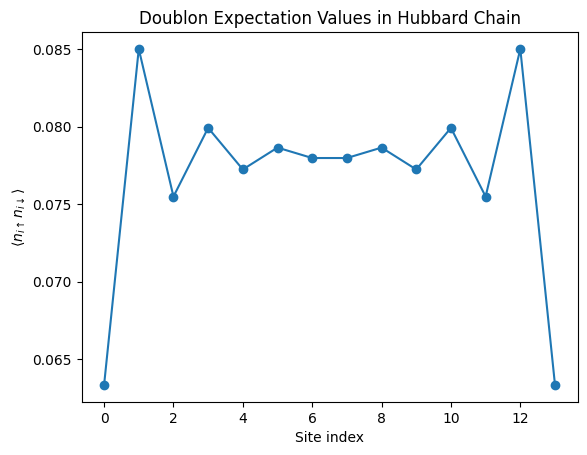

In [3]:
n_up = model.make_local_op_n_up()
n_down = model.make_local_op_n_down()
doublon = n_up * n_down

doublon_list = []
time_start = time.perf_counter()
for i in range(N):
    d = result.expectation_onsite(doublon, i)
    doublon_list.append(d)
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

plt.plot(range(N), doublon_list, marker="o")
plt.xlabel("Site index")
plt.ylabel(r"$\langle n_{i\uparrow} n_{i\downarrow} \rangle$")
plt.title("Doublon Expectation Values in Hubbard Chain")

Elapsed time: 3.570396291994257 sec


Text(0.5, 1.0, 'Spin Correlation Functions in Hubbard Chain')

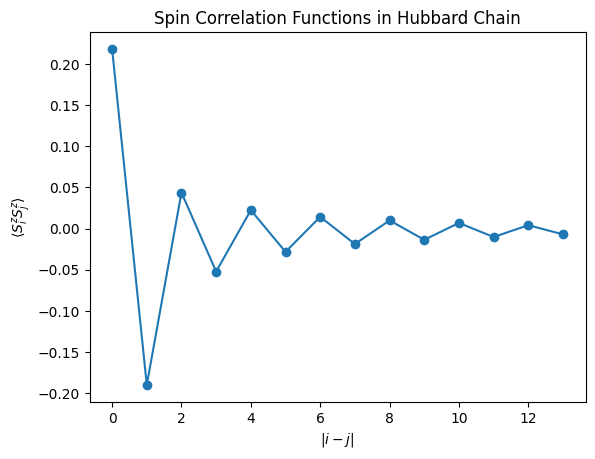

In [4]:
Sz = model.make_local_op_sz()
Sz_cfs = []
time_start = time.perf_counter()
for i in range(N):
    Sz_cfs.append(result.correlation_function(Sz, 0, Sz, i))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

plt.plot(range(N), Sz_cfs, marker="o")
plt.xlabel(r"$|i-j|$")
plt.ylabel(r"$\langle S_i^z S_j^z \rangle$")
plt.title("Spin Correlation Functions in Hubbard Chain")

Elapsed time: 4.339690000007977 sec


Text(0.5, 1.0, 'Charge Correlation (U=4.0)')

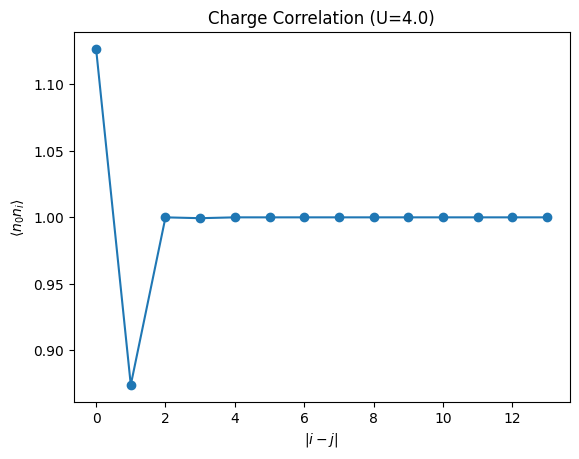

In [5]:
n = model.make_local_op_n()
n_cfs = []
time_start = time.perf_counter()
for i in range(N):
    n_cfs.append(result.correlation_function(n, 0, n, i))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

plt.plot(range(N), n_cfs, marker="o")
plt.xlabel(r"$|i-j|$")
plt.ylabel(r"$\langle n_0 n_i \rangle$")
plt.title(f"Charge Correlation (U={U})")